Codice utile a visualizzare quali Sub hanno apportato una maggiore variazione nelle metriche e visualizzarne graficamente l'andamento. 
Cambiare il percorso del csv all'interno del main().


════════════════════════════════════════════════════════════
  ANALISI VARIAZIONE FITNESS RISPETTO ALLA BASELINE
════════════════════════════════════════════════════════════

  Dataset: SEPSIS
  Baseline Fitness: 0.7074
────────────────────────────────────────────────────────────
  Sub          Scenario                             Δ Fitness
────────────────────────────────────────────────────────────
  Sub42        repaired_isolated_Sub42             ▲ +0.0161
  Sub16        repaired_isolated_Sub16             ▲ +0.0143
  Sub9         repaired_isolated_Sub9              ▲ +0.0112
  Sub72        repaired_isolated_Sub72             ▲ +0.0097
  Sub14        repaired_isolated_Sub14             ▲ +0.0084
  Sub80        repaired_isolated_Sub80             ▲ +0.0049
  Sub35        repaired_isolated_Sub35             ▲ +0.0029
  Sub106       repaired_isolated_Sub106            ▲ +0.0003
  Sub148       repaired_isolated_Sub148            ▲ +0.0002
  Sub327       repaired_isolated_Sub327       

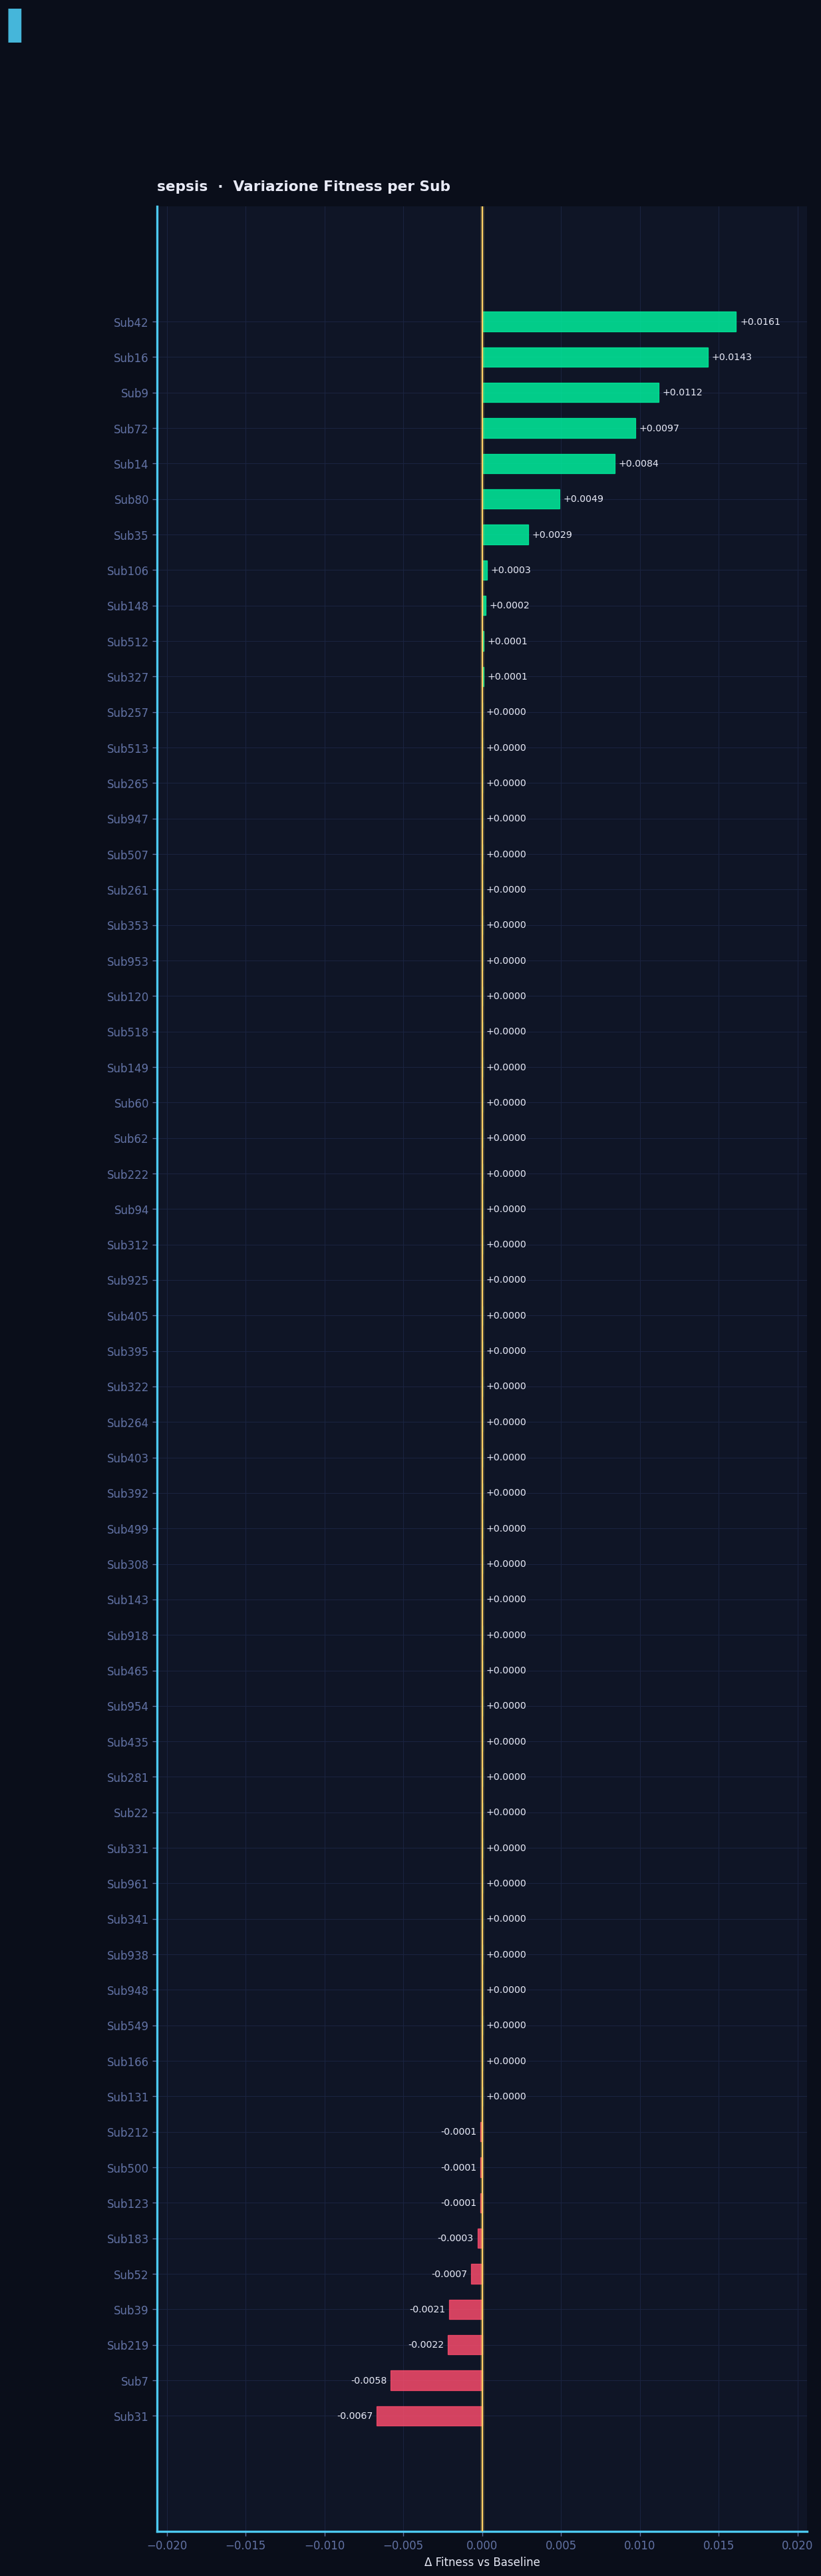

  → Salvato: Plots\_analisi_sepsis_2_metriche_linee.png


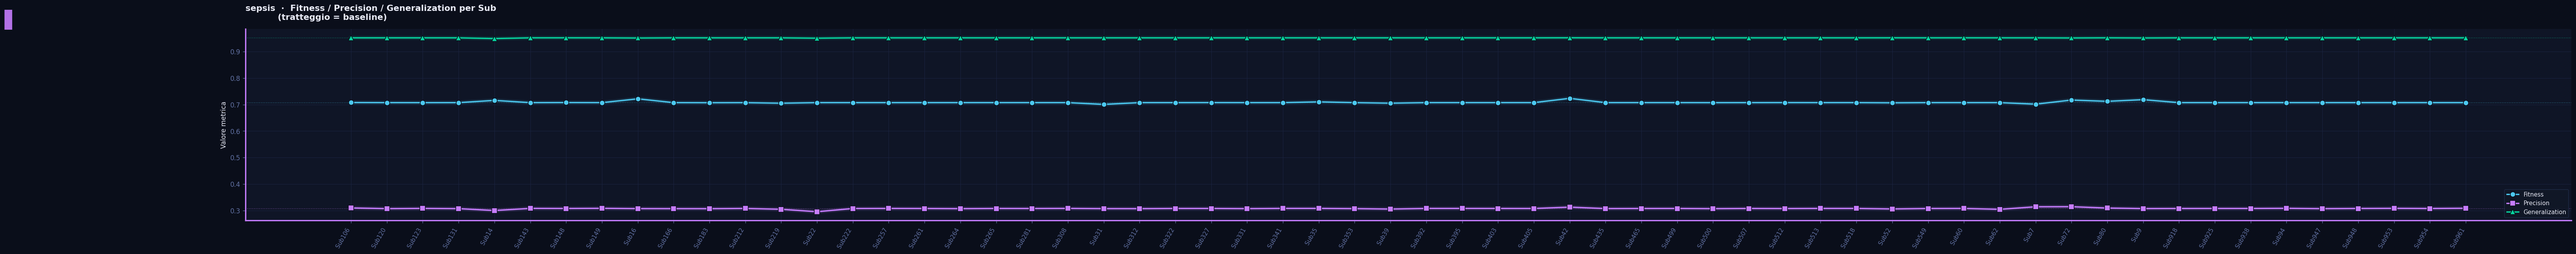

  → Salvato: Plots\_analisi_sepsis_3_scatter.png


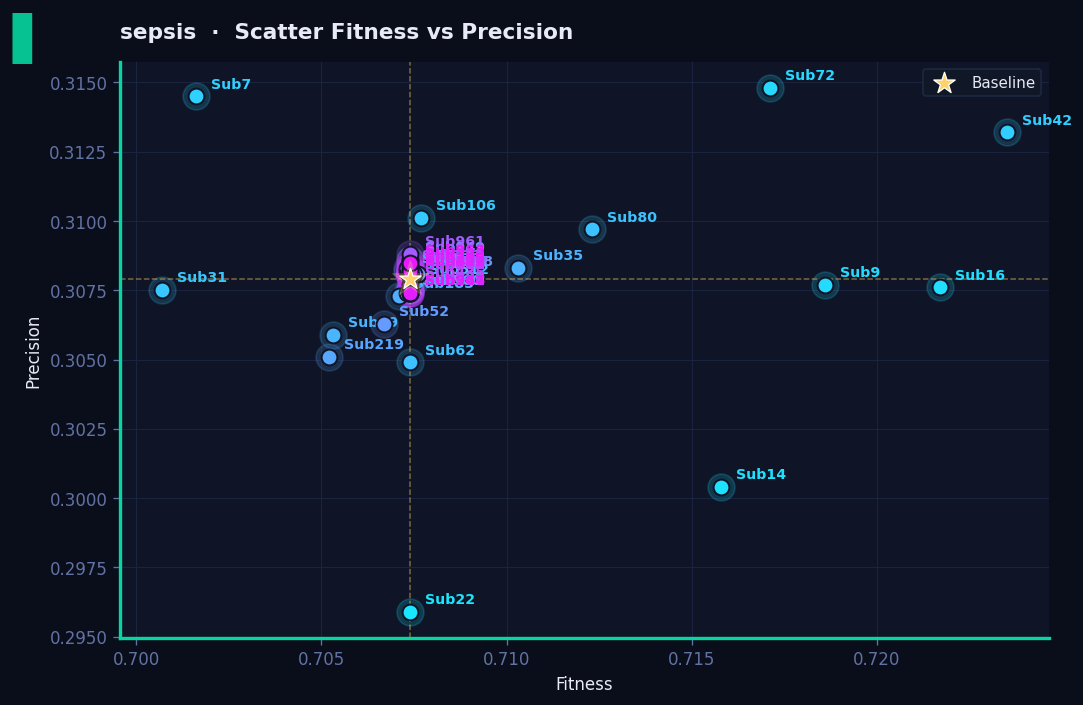

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Palette & stile globale ───────────────────────────────────────────────────
BG_FIGURE  = "#0a0e1a"   # blu notte profondo
BG_AXES    = "#0f1526"   # leggermente più chiaro per staccare
BORDER     = "#1e2a45"   # bordo sottile blu-acciaio
TEXT_MAIN  = "#e8eaf6"   # bianco freddo
TEXT_MUTED = "#6272a4"   # grigio viola
GRID_COL   = "#1a2340"   # griglia quasi invisibile

plt.rcParams.update({
    # Font: serif display per i titoli, sans moderno per i tick
    "font.family":          "DejaVu Sans",
    "font.size":            10,
    "axes.titlesize":       13,
    "axes.titleweight":     "bold",
    "axes.labelsize":       10,

    # Colori strutturali
    "figure.facecolor":     BG_FIGURE,
    "axes.facecolor":       BG_AXES,
    "axes.edgecolor":       BORDER,
    "axes.labelcolor":      TEXT_MAIN,
    "axes.spines.top":      False,
    "axes.spines.right":    False,

    # Tick
    "xtick.color":          TEXT_MUTED,
    "ytick.color":          TEXT_MUTED,
    "xtick.major.size":     4,
    "ytick.major.size":     4,
    "xtick.major.width":    0.8,
    "ytick.major.width":    0.8,

    # Griglia sottilissima, solo asse principale
    "grid.color":           GRID_COL,
    "grid.linestyle":       "-",
    "grid.linewidth":       0.6,
    "grid.alpha":           1.0,
    "axes.grid":            True,

    # Testo
    "text.color":           TEXT_MAIN,

    # Legenda raffinata
    "legend.facecolor":     "#111827",
    "legend.edgecolor":     BORDER,
    "legend.framealpha":    0.9,
    "legend.fontsize":      9,
    "legend.title_fontsize": 9,

    # Figure
    "figure.dpi":           120,
    "savefig.dpi":          150,
    "savefig.facecolor":    BG_FIGURE,
})

ACCENT_COLORS = {
    "positive":       "#00f5a0",   # verde neon acqua
    "negative":       "#ff4d6d",   # rosso corallo vivo
    "baseline":       "#ffd166",   # giallo ambra
    "fitness":        "#4cc9f0",   # ciano elettrico
    "precision":      "#c77dff",   # viola neon
    "generalization": "#06d6a0",   # verde smeraldo
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _fig_height_for_subs(n: int, min_h: float = 5.0, per_sub: float = 0.55) -> float:
    """Altezza figura proporzionale al numero di Sub sull'asse Y."""
    return max(min_h, n * per_sub + 2.5)

def _x_fig_width_for_subs(n: int, min_w: float = 8.0, per_sub: float = 0.9) -> float:
    """Larghezza figura proporzionale al numero di Sub sull'asse X."""
    return max(min_w, n * per_sub + 3.0)

def _style_fig(fig, ax, title: str, accent: str = "#4cc9f0"):
    """Applica titolo con accent-marker colorato e spine colorate."""
    fig.text(0.01, 0.97, "▌", transform=fig.transFigure,
             fontsize=30, color=accent, va="top", ha="left", alpha=0.9,
             clip_on=False)
    ax.set_title(title, fontsize=13, color=TEXT_MAIN, pad=14,
                 fontweight="bold", loc="left", x=0.0)
    for spine in ax.spines.values():
        spine.set_linewidth(0)
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["left"].set_edgecolor(accent)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(2.0)
    ax.spines["bottom"].set_edgecolor(accent)

# ── Caricamento dati ─────────────────────────────────────────────────────────
def load_data(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df["Sub"] = df["Scenario"].str.extract(r"(Sub\d+)", expand=False)
    df["Sub"] = df["Sub"].fillna("BASELINE")
    return df


# ── Analisi testuale ─────────────────────────────────────────────────────────
def print_ranking(df: pd.DataFrame):
    baseline_rows = df[df["Strategy"] == "BASELINE"]
    repair_rows   = df[df["Strategy"] == "REPAIR"]
    separator = "─" * 60

    print("\n" + "═" * 60)
    print("  ANALISI VARIAZIONE FITNESS RISPETTO ALLA BASELINE")
    print("═" * 60)

    for dataset in df["Dataset"].unique():
        bl = baseline_rows[baseline_rows["Dataset"] == dataset]["Fitness"].values
        if len(bl) == 0:
            continue
        baseline_fitness = bl[0]

        repairs = repair_rows[repair_rows["Dataset"] == dataset].copy()
        repairs["delta_fitness"] = repairs["Fitness"] - baseline_fitness
        repairs = repairs.sort_values("delta_fitness", ascending=False)

        print(f"\n  Dataset: {dataset.upper()}")
        print(f"  Baseline Fitness: {baseline_fitness:.4f}")
        print(separator)
        print(f"  {'Sub':<12} {'Scenario':<35} {'Δ Fitness':>10}")
        print(separator)

        for _, row in repairs.iterrows():
            delta = row["delta_fitness"]
            sign  = "▲" if delta > 0 else ("▼" if delta < 0 else "●")
            sub   = row["Sub"] if pd.notna(row["Sub"]) else "?"
            print(f"  {sub:<12} {row['Scenario']:<35} {sign} {delta:+.4f}")

        print(separator)
        best  = repairs.iloc[0]
        worst = repairs.iloc[-1]
        print(f"\n  🏆 Miglior incremento : {best['Sub']}  Δ = {best['delta_fitness']:+.4f}")
        print(f"  ⚠️  Peggior decremento : {worst['Sub']}  Δ = {worst['delta_fitness']:+.4f}")

    print("\n" + "═" * 60 + "\n")


# ── Grafico 1: Δ Fitness — bar chart ORIZZONTALE (Sub sull'asse Y) ────────────
def plot_delta_fitness(df: pd.DataFrame, dataset: str, out_prefix: str):
    baseline_fitness = df[
        (df["Dataset"] == dataset) & (df["Strategy"] == "BASELINE")
    ]["Fitness"].values[0]

    repairs = df[(df["Dataset"] == dataset) & (df["Strategy"] == "REPAIR")].copy()
    repairs["delta"] = repairs["Fitness"] - baseline_fitness
    repairs = repairs.sort_values("delta", ascending=True)

    n = len(repairs)
    fig, ax = plt.subplots(figsize=(11, _fig_height_for_subs(n)),
                           facecolor=BG_FIGURE)
    fig.subplots_adjust(left=0.18, right=0.92, top=0.90, bottom=0.08)

    colors = [ACCENT_COLORS["positive"] if d >= 0 else ACCENT_COLORS["negative"]
              for d in repairs["delta"]]

    bars = ax.barh(repairs["Sub"], repairs["delta"], color=colors,
                   height=0.55, zorder=3)

    # Etichette valori a destra/sinistra delle barre
    x_range = repairs["delta"].abs().max() or 0.01
    offset  = x_range * 0.015
    for bar, val in zip(bars, repairs["delta"]):
        xpos = bar.get_width()
        ha   = "left" if xpos >= 0 else "right"
        ax.text(xpos + (offset if xpos >= 0 else -offset),
                bar.get_y() + bar.get_height() / 2,
                f"{val:+.4f}", va="center", ha=ha,
                fontsize=8.5, color=TEXT_MAIN)

    # Trasparenza sulle barre + bordo colorato
    for bar, col in zip(bars, colors):
        bar.set_alpha(0.82)
        bar.set_edgecolor(col)
        bar.set_linewidth(0.8)

    # Linea zero con glow (doppio axvline)
    ax.axvline(0, color=ACCENT_COLORS["baseline"], linewidth=3.5,
               linestyle="-", zorder=4, alpha=0.25)
    ax.axvline(0, color=ACCENT_COLORS["baseline"], linewidth=1.2,
               linestyle="-", zorder=5)

    ax.set_xlabel("Δ Fitness vs Baseline", fontsize=10)
    ax.grid(axis="x", zorder=0)
    ax.set_axisbelow(True)
    lim = repairs["delta"].abs().max() * 1.28 or 0.01
    ax.set_xlim(-lim, lim)
    _style_fig(fig, ax, f"{dataset}  ·  Variazione Fitness per Sub",
               accent=ACCENT_COLORS["fitness"])

    out = f"{out_prefix}_1_delta_fitness.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG_FIGURE)
    print(f"  → Salvato: {out}")
    plt.show()
    plt.close(fig)


# ── Grafico 2: Line plot metriche per Sub (Sub sull'asse X) ──────────────────
def plot_metrics_per_sub(df: pd.DataFrame, dataset: str, out_prefix: str):
    baseline = df[(df["Dataset"] == dataset) & (df["Strategy"] == "BASELINE")].iloc[0]
    repairs  = df[(df["Dataset"] == dataset) & (df["Strategy"] == "REPAIR")].copy()
    repairs  = repairs.sort_values("Sub")

    subs = repairs["Sub"].tolist()
    n    = len(subs)
    x    = np.arange(n)

    fig, ax = plt.subplots(figsize=(_x_fig_width_for_subs(n), 6),
                           facecolor=BG_FIGURE)
    fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.22)

    metrics = [
        ("Fitness",        ACCENT_COLORS["fitness"],        "o"),
        ("Precision",      ACCENT_COLORS["precision"],      "s"),
        ("Generalization", ACCENT_COLORS["generalization"], "^"),
    ]

    for metric, color, marker in metrics:
        values = repairs[metric].values
        # Glow effect: linea spessa semitrasparente sotto
        ax.plot(x, values, color=color, linewidth=6, alpha=0.15, zorder=2)
        ax.plot(x, values, color=color, marker=marker, linewidth=2,
                markersize=8, label=metric, zorder=3,
                markeredgecolor=BG_FIGURE, markeredgewidth=1.0)
        ax.axhline(baseline[metric], color=color, linewidth=1,
                   linestyle=":", alpha=0.45, zorder=2)

    ax.set_xticks(x)
    ax.set_xticklabels(subs, rotation=60, ha="right", fontsize=9)
    ax.tick_params(axis="x", pad=6)
    ax.set_ylabel("Valore metrica", fontsize=10)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(zorder=0)
    ax.set_axisbelow(True)
    _style_fig(fig, ax,
               f"{dataset}  ·  Fitness / Precision / Generalization per Sub\n"
               f"           (tratteggio = baseline)",
               accent=ACCENT_COLORS["precision"])

    out = f"{out_prefix}_2_metriche_linee.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG_FIGURE)
    print(f"  → Salvato: {out}")
    plt.show()
    plt.close(fig)


# ── Grafico 3: Scatter Fitness vs Precision ──────────────────────────────────
def plot_scatter(df: pd.DataFrame, dataset: str, out_prefix: str):
    baseline = df[(df["Dataset"] == dataset) & (df["Strategy"] == "BASELINE")].iloc[0]
    repairs  = df[(df["Dataset"] == dataset) & (df["Strategy"] == "REPAIR")].copy()

    cmap   = plt.cm.cool
    colors = cmap(np.linspace(0.1, 0.9, len(repairs)))

    fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG_FIGURE)
    fig.subplots_adjust(left=0.11, right=0.97, top=0.90, bottom=0.10)

    for i, (_, row) in enumerate(repairs.iterrows()):
        # Glow: cerchio grande semitrasparente sotto
        ax.scatter(row["Fitness"], row["Precision"],
                   color=colors[i], s=260, zorder=2, alpha=0.18)
        ax.scatter(row["Fitness"], row["Precision"],
                   color=colors[i], s=90, zorder=3,
                   edgecolors=BG_AXES, linewidths=1.2)
        ax.annotate(row["Sub"], (row["Fitness"], row["Precision"]),
                    textcoords="offset points", xytext=(9, 5),
                    fontsize=8.5, color=colors[i], fontweight="bold")

    # Baseline con stella + glow
    ax.scatter(baseline["Fitness"], baseline["Precision"],
               color=ACCENT_COLORS["baseline"], s=500, marker="*",
               zorder=4, alpha=0.2)
    ax.scatter(baseline["Fitness"], baseline["Precision"],
               color=ACCENT_COLORS["baseline"], s=180, marker="*",
               zorder=5, edgecolors="white", linewidths=0.8, label="Baseline")
    ax.axvline(baseline["Fitness"],  color=ACCENT_COLORS["baseline"],
               linewidth=0.9, linestyle="--", alpha=0.45)
    ax.axhline(baseline["Precision"], color=ACCENT_COLORS["baseline"],
               linewidth=0.9, linestyle="--", alpha=0.45)

    ax.set_xlabel("Fitness", fontsize=10)
    ax.set_ylabel("Precision", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(zorder=0)
    ax.set_axisbelow(True)
    _style_fig(fig, ax, f"{dataset}  ·  Scatter Fitness vs Precision",
               accent=ACCENT_COLORS["generalization"])

    out = f"{out_prefix}_3_scatter.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=BG_FIGURE)
    print(f"  → Salvato: {out}")
    plt.show()
    plt.close(fig)


# ── Main ─────────────────────────────────────────────────────────────────────
def main():
    df = load_data("C:\\Users\\gabri\\OneDrive\\Desktop\\Progetti UNIVPM\\BigDataProcessMining\\results\\new_experiments_matrix_sepsis_isolated_freq_sort.csv")

    print_ranking(df)

    for dataset in df["Dataset"].unique():
        prefix = f"Plots\\_analisi_{dataset}"
        print(f"\n─── Generazione grafici per dataset: {dataset.upper()} ───")
        plot_delta_fitness(df, dataset, prefix)
        plot_metrics_per_sub(df, dataset, prefix)
        plot_scatter(df, dataset, prefix)


if __name__ == "__main__":
    main()
